In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import NullFormatter
import datetime as dt
import pandas as pd

%matplotlib inline

In [2]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39485,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44341,Total threads: 2
Dashboard: /proxy/46881/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:46485,


2025-12-05 16:36:48,123 - tornado.application - ERROR - Uncaught exception GET /individual-workers-memory/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0201.gadi.nci.org.au:22146', method='GET', uri='/individual-workers-memory/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolE

### load clim and thresholds

In [3]:
thresh = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/om2_025_MLT_thresh.nc')
clim = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/om2_025_MLT_clim.nc')
temp = xr.open_dataset('/scratch/m35/nm5072/TAS_thresholds/TAS_MLD_ready.zarr')

In [4]:
#thresh=thresh.rename({'__xarray_dataarray_variable__': 'temp'})

In [5]:
clim_box   = clim.temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38))
thresh_box = thresh.temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38))
temp_box   = (temp.sel(time=slice('2017-10-01','2018-03-01'))
                  .temp.sel(xt_ocean=slice(-210, -192), yt_ocean=slice(-44, -38)))

clim_mean = clim_box.mean(dim=('xt_ocean', 'yt_ocean'))
thresh_mean = thresh_box.mean(dim=('xt_ocean', 'yt_ocean'))
temp_mean = temp_box.sel(time=slice('2017-10-01','2018-03-01')).mean(dim=('xt_ocean', 'yt_ocean'))

In [6]:
# # Pick the midpoint indices of the domain
# ix = clim.sizes['xt_ocean'] // 2
# iy = clim.sizes['yt_ocean'] // 2

# # (Optional) grab the actual lon/lat of that point for reference
# lon0 = float(clim['xt_ocean'].isel(xt_ocean=ix))
# lat0 = float(clim['yt_ocean'].isel(yt_ocean=iy))
# print(f"Central point selected at lon={lon0:.3f}, lat={lat0:.3f}")

# # Select the central point instead of averaging
# clim_mean   = clim.temp.isel(xt_ocean=ix, yt_ocean=iy)  # dims: dayofyear
# thresh_mean = thresh.temp.isel(xt_ocean=ix, yt_ocean=iy)  # dims: dayofyear
# temp_mean   = (
#     temp.sel(time=slice('2017-09-01', '2017-12-31'))
#         .temp.isel(xt_ocean=ix, yt_ocean=iy)             # dim: time
# )

#### fix smoothing - need to investigate why this happened in the toolbox

In [7]:
# def smooth_cyclic_1d(da, dim='dayofyear', window=31):
#     """Centered moving-average that wraps around the DOY cycle."""
#     assert window % 2 == 1, "Use an odd window (e.g., 11)."
#     vals = da.values
#     pad = np.pad(vals, (window//2, window//2), mode='wrap')
#     kernel = np.ones(window, dtype=float) / window
#     sm = np.convolve(pad, kernel, mode='valid')
#     return xr.DataArray(sm, coords={dim: da[dim]}, dims=[dim], attrs=da.attrs, name=getattr(da, 'name', None))

# # Smooth DOY series (Hobday-style often uses 11-day)
# clim_mean   = smooth_cyclic_1d(clim_mean,   window=11)
# thresh_mean = smooth_cyclic_1d(thresh_mean, window=11)

# # Map smoothed DOY series onto your time axis
# doy = temp_mean['time'].dt.dayofyear
# clim_on_time   = clim_mean_s.sel(dayofyear=doy)
# thresh_on_time = thresh_mean_s.sel(dayofyear=doy)

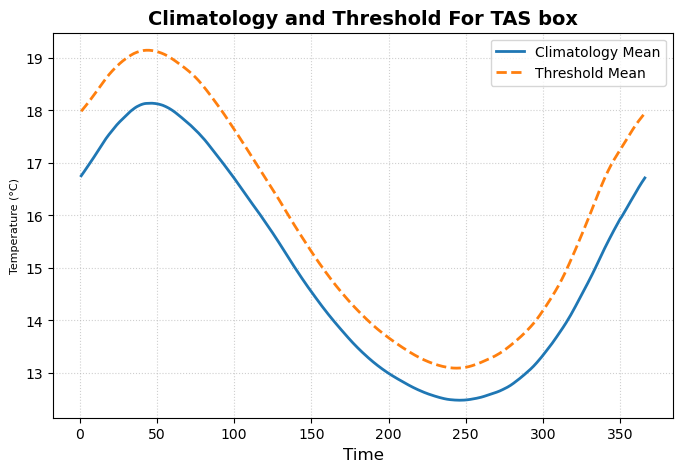

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

clim_mean.plot(ax=ax, label='Climatology Mean', color='C0', linewidth=2)
thresh_mean.plot(ax=ax, label='Threshold Mean', color='C1', linewidth=2, linestyle='--')

ax.set_title('Climatology and Threshold For TAS box', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=8)
ax.legend(fontsize=10, loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

/jobfs/156022541.gadi-pbs/ipykernel_1388372/4077239065.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lab = (long_true.diff(1).fillna(False) | (~long_true).shift(1, fill_value=False) & long_true).cumsum()


Text(5, 5, '29 Nov 2017')

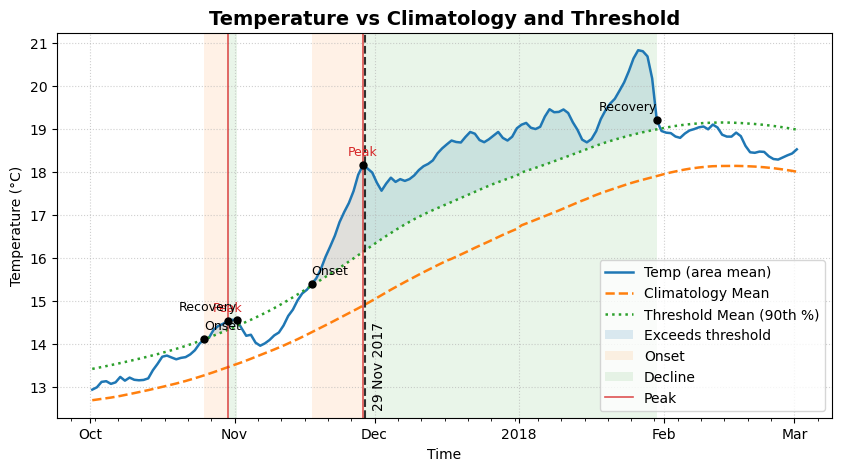

In [9]:
# --- indices on the seasonal cycle you already have ---
doy = temp_mean['time'].dt.dayofyear
clim_on_time   = clim_mean.sel(dayofyear=doy)
thresh_on_time = thresh_mean.sel(dayofyear=doy)

# --- plot the timeseries + threshold/clim ---
fig, ax = plt.subplots(figsize=(10, 5))
temp_mean.plot(ax=ax, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# --- shaded exceedances (as before) ---
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
valid  = np.isfinite(y_temp) & np.isfinite(y_thr)
ax.fill_between(t[valid], y_thr[valid], y_temp[valid],
                where=(y_temp[valid] > y_thr[valid]), alpha=0.15, label='Exceeds threshold')

# ---------- PHASE DETECTION & ANNOTATION ----------
import pandas as pd

# Parameters for Hobday-style event definition
MIN_DUR = 5     # minimum duration (days)
MAX_GAP = 2     # merge gaps <= 2 days

time_idx = pd.to_datetime(t[valid])
exceed   = (y_temp[valid] > y_thr[valid])
series   = pd.Series(exceed, index=time_idx).astype(int)

# Merge short gaps: any False-runs of length <= MAX_GAP become True
runs = (series.diff(1).ne(0)).cumsum()
run_lengths = series.groupby(runs).transform('size')
is_false_run = (series == 0)
short_false  = is_false_run & (run_lengths <= MAX_GAP)
series_merged = series.copy()
series_merged[short_false] = 1

# Recompute runs on merged series and pick only True-runs with length >= MIN_DUR
runs2 = (series_merged.diff(1).ne(0)).cumsum()
lens2 = series_merged.groupby(runs2).transform('size')
is_true_run = (series_merged == 1)
long_true   = is_true_run & (lens2 >= MIN_DUR)

# Extract contiguous event segments
events = []
if long_true.any():
    lab = (long_true.diff(1).fillna(False) | (~long_true).shift(1, fill_value=False) & long_true).cumsum()
    # Simpler: iterate over contiguous blocks where long_true is True
    start_i = None
    arr = long_true.to_numpy()
    idx = long_true.index.to_numpy()
    for i in range(len(arr)):
        if arr[i] and start_i is None:
            start_i = i
        if start_i is not None and (i == len(arr)-1 or not arr[i+1]):
            # end of block at i
            s, e = start_i, i
            events.append((idx[s], idx[e]))
            start_i = None

# Annotate each event with phases
anom = (y_temp[valid] - y_thr[valid])
anom_series = pd.Series(anom, index=time_idx)

for k, (t_start, t_end) in enumerate(events, start=1):
    # Peak = time of maximum anomaly within event
    seg = anom_series.loc[t_start:t_end]
    t_peak = seg.idxmax()

    # Visual spans for phases
    ax.axvspan(t_start, t_peak, alpha=0.10, facecolor='tab:orange', label='Onset' if k == 1 else None)
    ax.axvspan(t_peak,  t_end,  alpha=0.10, facecolor='tab:green',  label='Decline' if k == 1 else None)

    # Markers + thin lines down to curve
    ax.axvline(t_peak, color='tab:red', linestyle='-', linewidth=1.2, alpha=0.8,
               label='Peak' if k == 1 else None)
    ax.scatter([t_start, t_peak, t_end],
               [temp_mean.sel(time=t_start).item(),
                temp_mean.sel(time=t_peak).item(),
                temp_mean.sel(time=t_end).item()],
               s=25, zorder=5, color='k')

    # Text labels (nudged)
    y0 = temp_mean.sel(time=t_start).item()
    y1 = temp_mean.sel(time=t_peak).item()
    y2 = temp_mean.sel(time=t_end).item()
    ax.text(t_start, y0 + 0.15, 'Onset', fontsize=9, ha='left', va='bottom')
    ax.text(t_peak,  y1 + 0.15, 'Peak',  fontsize=9, ha='center', va='bottom', color='tab:red')
    ax.text(t_end,   y2 + 0.15, 'Recovery', fontsize=9, ha='right', va='bottom')

# ---------- formatting ----------
ax.set_title('Temperature vs Climatology and Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Time'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best'); ax.grid(True, linestyle=':', alpha=0.6)

locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_minor_formatter(NullFormatter())

# Existing vertical line for your spatial plots
date = dt.datetime(2017, 11, 29)
ax.axvline(date, color='k', linestyle='--', linewidth=1.5, alpha=0.8)
label_str = date.strftime('%-d %b %Y')
ax.annotate(label_str, xy=(date, ax.get_ylim()[0]), xycoords='data',
            xytext=(5, 5), textcoords='offset points', rotation=90, va='bottom', ha='left')


### plot spatial maps


In [10]:
def plotmap(data, ax=None, extent=None, lon_name='xt_ocean', lat_name='yt_ocean'):
    """Simple Cartopy map (regional), using given coord names."""
    if ax is None:
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(6, 4.5))
    else:
        fig = None

    lon = np.asarray(data[lon_name])
    lat = np.asarray(data[lat_name])
    if extent is None:
        extent = [float(np.nanmin(lon)), float(np.nanmax(lon)),
                  float(np.nanmin(lat)), float(np.nanmax(lat))]

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.9', edgecolor='none')
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    return fig, ax


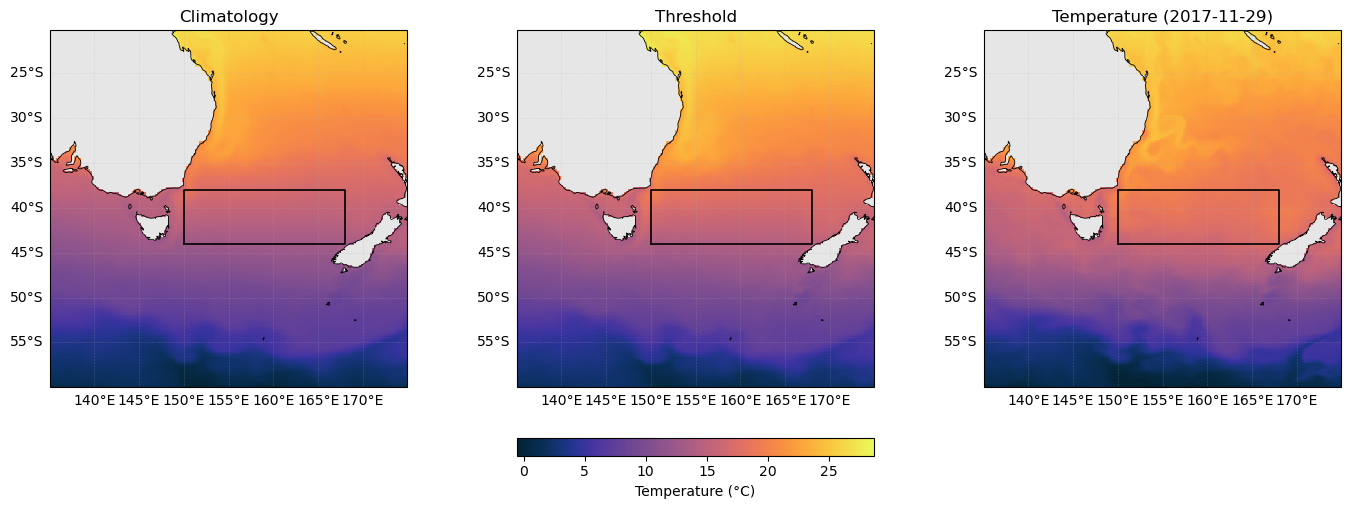

In [11]:
# Convert target lons to ACCESS-OM convention (your grid: -224..-185)
lon_min_ds, lon_max_ds = -210, -192   # 150E, 168E
lat_min, lat_max       = -44, -38

# --- choose date ---
date = '2017-11-29'
doy = pd.to_datetime(date).dayofyear

# Select fields
clim_on_date   = clim.temp.sel(dayofyear=doy)
thresh_on_date = thresh.temp.sel(dayofyear=doy)
temp_on_date   = temp.temp.sel(time=date, method='nearest')

# Common color scale
vmin = float(np.nanmin([clim_on_date.min().item(),
                        thresh_on_date.min().item(),
                        temp_on_date.min().item()]))
vmax = float(np.nanmax([clim_on_date.max().item(),
                        thresh_on_date.max().item(),
                        temp_on_date.max().item()]))

# Figure with three maps
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(14, 5),
                         subplot_kw={'projection': proj},
                         constrained_layout=True)

panels = [
    (clim_on_date,   'Climatology'),
    (thresh_on_date, 'Threshold'),
    (temp_on_date,   f"Temperature ({pd.to_datetime(temp_on_date['time'].values).date()})"),
]

for ax, (da, title) in zip(axes, panels):
    plotmap(da, ax=ax, lon_name='xt_ocean', lat_name='yt_ocean')
    im = da.plot.pcolormesh(
        ax=ax, transform=proj,
        cmap=cmo.thermal, vmin=vmin, vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=12)

    # Add black box
    box_lons = [lon_min_ds, lon_max_ds, lon_max_ds, lon_min_ds, lon_min_ds]
    box_lats = [lat_min,    lat_min,    lat_max,    lat_max,    lat_min]
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='horizontal', fraction=0.05, pad=0.08)
cbar.set_label('Temperature (°C)')



### make combined plot

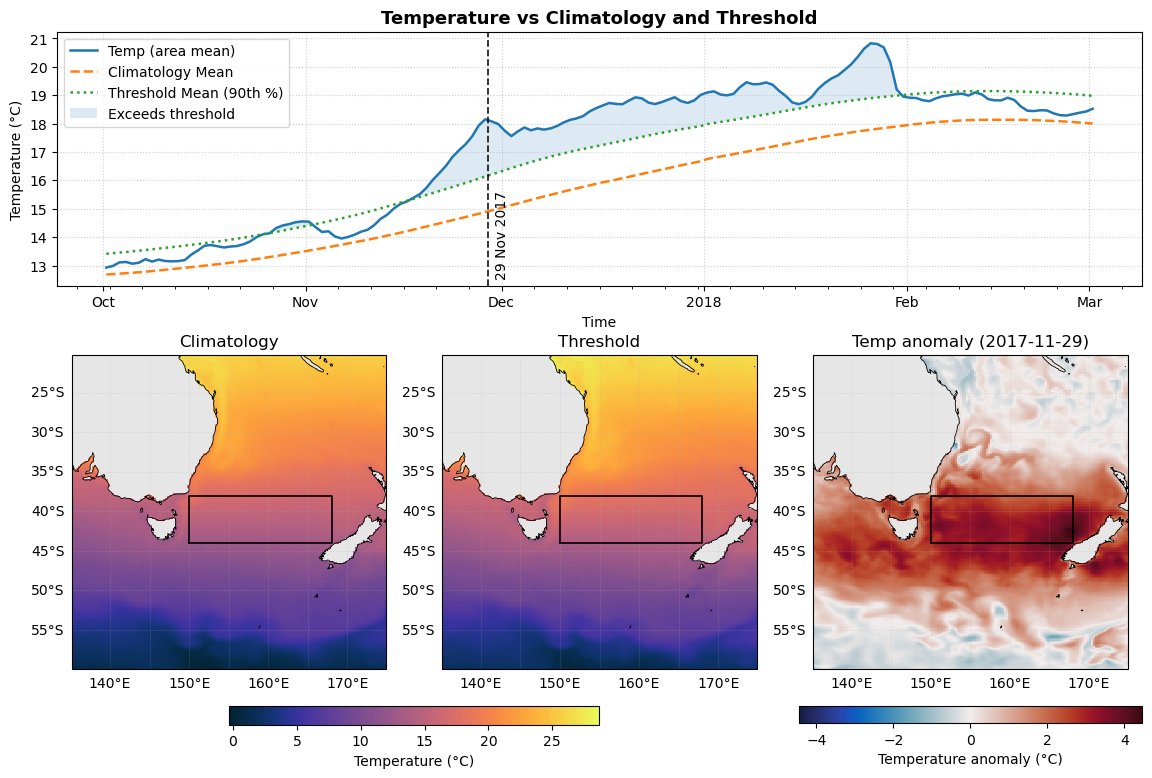

In [12]:
# -------- Subset box (degrees east / south) --------
lon_min_e, lon_max_e = 150.0, 168.0
lat_min,   lat_max   = -44.0, -38.0

def map_lon_to_ds(lon_e, lon_coord):
    lonmin = float(lon_coord.min()); lonmax = float(lon_coord.max())
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0
    if lonmax <= 100.0 and lonmin < -180.0:  # ACCESS-style
        return lon_e if lon_e <= lonmax else lon_e - 360.0
    return lon_e

lon_left  = map_lon_to_ds(lon_min_e, clim['xt_ocean'])
lon_right = map_lon_to_ds(lon_max_e, clim['xt_ocean'])
lon_left, lon_right = sorted([lon_left, lon_right])
lat_bot,  lat_top   = sorted([lat_min,  lat_max])

# -------- Date for the vertical line + maps --------
date = dt.datetime(2017, 11, 29)
doy  = pd.to_datetime(date).dayofyear

# -------- Fields for the maps --------
clim_on_date    = clim.temp.sel(dayofyear=doy)               # absolute
thresh_on_date  = thresh.temp.sel(dayofyear=doy)             # absolute
temp_on_date    = temp.temp.sel(time=date, method='nearest') # absolute
temp_anom_on_date = temp_on_date - clim_on_date              # ANOMALY

# Colour scales:
# 1) Absolute fields (clim, thresh) share a thermal scale
vmin_abs = float(np.nanmin([clim_on_date.min().item(), thresh_on_date.min().item()]))
vmax_abs = float(np.nanmax([clim_on_date.max().item(), thresh_on_date.max().item()]))

# 2) Anomaly field uses symmetric range around 0 with a diverging colormap
amax = float(np.nanmax(np.abs(temp_anom_on_date.values)))
vmin_anom, vmax_anom = -amax, amax

# -------- Align climatology/threshold to time for the top plot --------
doy_series     = temp_mean['time'].dt.dayofyear
clim_on_time   = clim_mean.sel(dayofyear=doy_series)
thresh_on_time = thresh_mean.sel(dayofyear=doy_series)

# ================= FIGURE =================
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.1, 1.6], hspace=0.22, wspace=0.08)

# Top: time series across all columns
ax_ts = fig.add_subplot(gs[0, :])

# Bottom: three maps
ax_c  = fig.add_subplot(gs[1, 0], projection=proj)
ax_th = fig.add_subplot(gs[1, 1], projection=proj)
ax_tm = fig.add_subplot(gs[1, 2], projection=proj)
axes_maps = [ax_c, ax_th, ax_tm]

# ---- Top time series ----
temp_mean.plot(ax=ax_ts, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax_ts, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax_ts, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# Shaded exceedances
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
mask   = np.isfinite(y_temp) & np.isfinite(y_thr)
ax_ts.fill_between(t[mask], y_thr[mask], y_temp[mask],
                   where=(y_temp[mask] > y_thr[mask]),
                   alpha=0.15, label='Exceeds threshold')

# Vertical line + label at bottom
ax_ts.axvline(date, color='k', linestyle='--', linewidth=1.3, alpha=0.85)
ax_ts.annotate(date.strftime('%-d %b %Y'),
               xy=(date, ax_ts.get_ylim()[0]), xycoords='data',
               xytext=(5, 5), textcoords='offset points',
               rotation=90, va='bottom', ha='left')

# Axis formatting
ax_ts.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax_ts.set_xlabel('Time'); ax_ts.set_ylabel('Temperature (°C)')
ax_ts.legend(loc='best'); ax_ts.grid(True, linestyle=':', alpha=0.6)
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax_ts.xaxis.set_major_locator(locator)
ax_ts.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_minor_formatter(NullFormatter())

# ---- Bottom maps (use your existing plotmap) ----
# Left: Climatology (absolute)
try:
    plotmap(clim_on_date, ax=ax_c, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(clim_on_date, ax=ax_c)
im_abs1 = clim_on_date.plot.pcolormesh(ax=ax_c, transform=proj,
                                       cmap=cmo.thermal, vmin=vmin_abs, vmax=vmax_abs,
                                       add_colorbar=False)
ax_c.set_title('Climatology', fontsize=12)

# Middle: Threshold (absolute)
try:
    plotmap(thresh_on_date, ax=ax_th, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(thresh_on_date, ax=ax_th)
im_abs2 = thresh_on_date.plot.pcolormesh(ax=ax_th, transform=proj,
                                         cmap=cmo.thermal, vmin=vmin_abs, vmax=vmax_abs,
                                         add_colorbar=False)
ax_th.set_title('Threshold', fontsize=12)

# Right: Temperature anomaly (Temp − Climatology)
try:
    plotmap(temp_anom_on_date, ax=ax_tm, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(temp_anom_on_date, ax=ax_tm)
im_anom = temp_anom_on_date.plot.pcolormesh(ax=ax_tm, transform=proj,
                                            cmap=cmo.balance, vmin=vmin_anom, vmax=vmax_anom,
                                            add_colorbar=False)
ax_tm.set_title(f"Temp anomaly ({pd.to_datetime(temp_on_date['time'].values).date()})", fontsize=12)

# Black subset box on all three
box_lons = [lon_left, lon_right, lon_right, lon_left, lon_left]
box_lats = [lat_bot,  lat_bot,   lat_top,   lat_top,  lat_bot]
for ax in axes_maps:
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

# Colorbars: shared ABS for first two; separate ANOM for the right panel
cbar_abs  = fig.colorbar(im_abs2, ax=[ax_c, ax_th], orientation='horizontal', fraction=0.05, pad=0.1)
cbar_abs.set_label('Temperature (°C)')

cbar_anom = fig.colorbar(im_anom, ax=ax_tm, orientation='horizontal', fraction=0.05, pad=0.1)
cbar_anom.set_label('Temperature anomaly (°C)')

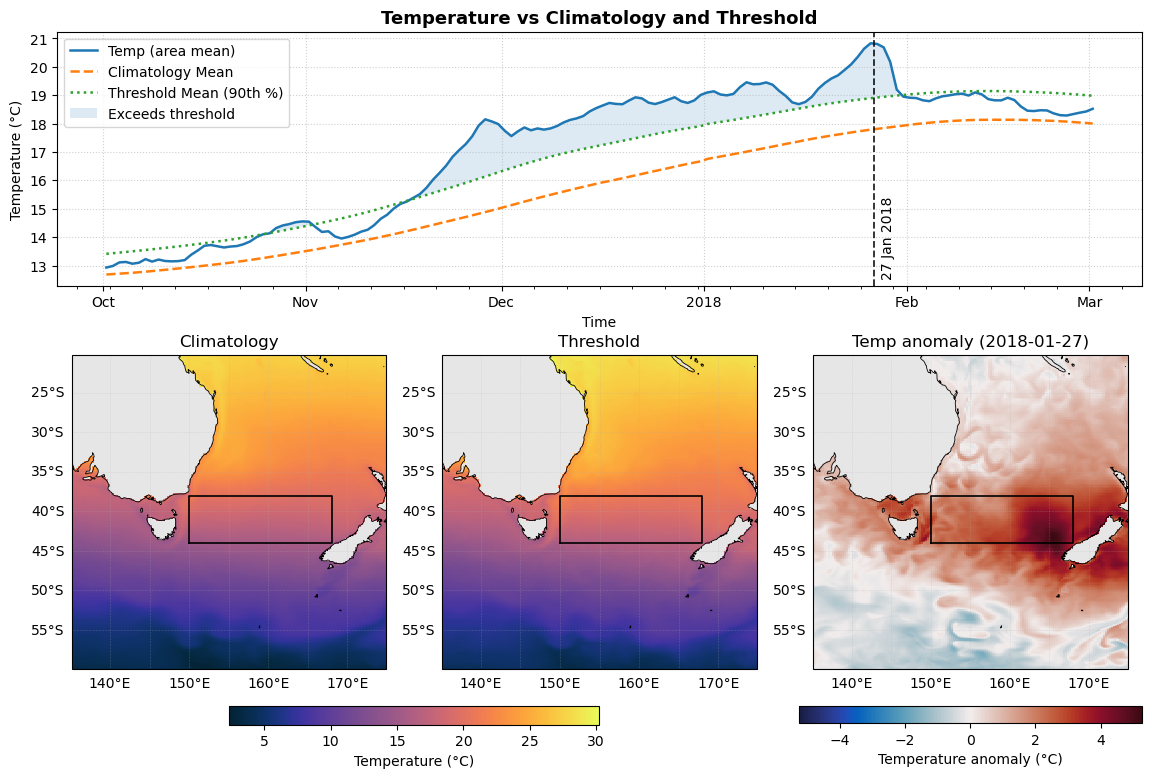

In [13]:
# -------- Subset box (degrees east / south) --------
lon_min_e, lon_max_e = 150.0, 168.0
lat_min,   lat_max   = -44.0, -38.0

def map_lon_to_ds(lon_e, lon_coord):
    lonmin = float(lon_coord.min()); lonmax = float(lon_coord.max())
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0
    if lonmax <= 100.0 and lonmin < -180.0:  # ACCESS-style
        return lon_e if lon_e <= lonmax else lon_e - 360.0
    return lon_e

lon_left  = map_lon_to_ds(lon_min_e, clim['xt_ocean'])
lon_right = map_lon_to_ds(lon_max_e, clim['xt_ocean'])
lon_left, lon_right = sorted([lon_left, lon_right])
lat_bot,  lat_top   = sorted([lat_min,  lat_max])

# -------- Date for the vertical line + maps --------
date = dt.datetime(2018, 1, 27)
doy  = pd.to_datetime(date).dayofyear

# -------- Fields for the maps --------
clim_on_date    = clim.temp.sel(dayofyear=doy)               # absolute
thresh_on_date  = thresh.temp.sel(dayofyear=doy)             # absolute
temp_on_date    = temp.temp.sel(time=date, method='nearest') # absolute
temp_anom_on_date = temp_on_date - clim_on_date              # ANOMALY

# Colour scales:
# 1) Absolute fields (clim, thresh) share a thermal scale
vmin_abs = float(np.nanmin([clim_on_date.min().item(), thresh_on_date.min().item()]))
vmax_abs = float(np.nanmax([clim_on_date.max().item(), thresh_on_date.max().item()]))

# 2) Anomaly field uses symmetric range around 0 with a diverging colormap
amax = float(np.nanmax(np.abs(temp_anom_on_date.values)))
vmin_anom, vmax_anom = -amax, amax

# -------- Align climatology/threshold to time for the top plot --------
doy_series     = temp_mean['time'].dt.dayofyear
clim_on_time   = clim_mean.sel(dayofyear=doy_series)
thresh_on_time = thresh_mean.sel(dayofyear=doy_series)

# ================= FIGURE =================
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.1, 1.6], hspace=0.22, wspace=0.08)

# Top: time series across all columns
ax_ts = fig.add_subplot(gs[0, :])

# Bottom: three maps
ax_c  = fig.add_subplot(gs[1, 0], projection=proj)
ax_th = fig.add_subplot(gs[1, 1], projection=proj)
ax_tm = fig.add_subplot(gs[1, 2], projection=proj)
axes_maps = [ax_c, ax_th, ax_tm]

# ---- Top time series ----
temp_mean.plot(ax=ax_ts, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax_ts, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax_ts, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# Shaded exceedances
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
mask   = np.isfinite(y_temp) & np.isfinite(y_thr)
ax_ts.fill_between(t[mask], y_thr[mask], y_temp[mask],
                   where=(y_temp[mask] > y_thr[mask]),
                   alpha=0.15, label='Exceeds threshold')

# Vertical line + label at bottom
ax_ts.axvline(date, color='k', linestyle='--', linewidth=1.3, alpha=0.85)
ax_ts.annotate(date.strftime('%-d %b %Y'),
               xy=(date, ax_ts.get_ylim()[0]), xycoords='data',
               xytext=(5, 5), textcoords='offset points',
               rotation=90, va='bottom', ha='left')

# Axis formatting
ax_ts.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax_ts.set_xlabel('Time'); ax_ts.set_ylabel('Temperature (°C)')
ax_ts.legend(loc='best'); ax_ts.grid(True, linestyle=':', alpha=0.6)
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax_ts.xaxis.set_major_locator(locator)
ax_ts.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_minor_formatter(NullFormatter())

# ---- Bottom maps (use your existing plotmap) ----
# Left: Climatology (absolute)
try:
    plotmap(clim_on_date, ax=ax_c, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(clim_on_date, ax=ax_c)
im_abs1 = clim_on_date.plot.pcolormesh(ax=ax_c, transform=proj,
                                       cmap=cmo.thermal, vmin=vmin_abs, vmax=vmax_abs,
                                       add_colorbar=False)
ax_c.set_title('Climatology', fontsize=12)

# Middle: Threshold (absolute)
try:
    plotmap(thresh_on_date, ax=ax_th, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(thresh_on_date, ax=ax_th)
im_abs2 = thresh_on_date.plot.pcolormesh(ax=ax_th, transform=proj,
                                         cmap=cmo.thermal, vmin=vmin_abs, vmax=vmax_abs,
                                         add_colorbar=False)
ax_th.set_title('Threshold', fontsize=12)

# Right: Temperature anomaly (Temp − Climatology)
try:
    plotmap(temp_anom_on_date, ax=ax_tm, lon_name='xt_ocean', lat_name='yt_ocean')
except TypeError:
    plotmap(temp_anom_on_date, ax=ax_tm)
im_anom = temp_anom_on_date.plot.pcolormesh(ax=ax_tm, transform=proj,
                                            cmap=cmo.balance, vmin=vmin_anom, vmax=vmax_anom,
                                            add_colorbar=False)
ax_tm.set_title(f"Temp anomaly ({pd.to_datetime(temp_on_date['time'].values).date()})", fontsize=12)

# Black subset box on all three
box_lons = [lon_left, lon_right, lon_right, lon_left, lon_left]
box_lats = [lat_bot,  lat_bot,   lat_top,   lat_top,  lat_bot]
for ax in axes_maps:
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

# Colorbars: shared ABS for first two; separate ANOM for the right panel
cbar_abs  = fig.colorbar(im_abs2, ax=[ax_c, ax_th], orientation='horizontal', fraction=0.05, pad=0.1)
cbar_abs.set_label('Temperature (°C)')

cbar_anom = fig.colorbar(im_anom, ax=ax_tm, orientation='horizontal', fraction=0.05, pad=0.1)
cbar_anom.set_label('Temperature anomaly (°C)')

In [14]:
# Go back further in time (start of October
# plot mixed layer depth
# fix threshold
# temp anomaly snapshots as the bottom spatial plots

# plot timeseries of budget terms (online budget only) - anomalies, maybe add surf flux and shortwave penetration together
#  -experiment with smoothing

### load budget terms

In [15]:
budget2017 = xr.open_mfdataset('/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/post_processed_diags/mlt_budget_stavg_daily_online_output364.nc')
budget2018 = xr.open_mfdataset('/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/post_processed_diags/mlt_budget_stavg_daily_online_output365.nc')

In [16]:
budget = xr.concat([budget2017, budget2018], dim='time')

In [17]:
budget_clim = xr.open_dataset('/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/post_processed_diags/mlt_budget_stavg_daily_online_output336-365_monthly_mean.ncea.nc')
budget_clim

<xarray.Dataset> Size: 1GB
Dimensions:          (time: 12, yt_ocean: 1080, xt_ocean: 1440)
Coordinates:
  * time             (time) datetime64[ns] 96B 1989-01-16T12:00:00 ... 1989-1...
  * yt_ocean         (yt_ocean) float64 9kB -81.08 -80.97 -80.87 ... 89.84 89.95
  * xt_ocean         (xt_ocean) float64 12kB -279.9 -279.6 ... 79.62 79.88
Data variables:
    fixedh_tendency  (time, yt_ocean, xt_ocean) float32 75MB ...
    advection        (time, yt_ocean, xt_ocean) float32 75MB ...
    vert_mixing      (time, yt_ocean, xt_ocean) float32 75MB ...
    surface_flux     (time, yt_ocean, xt_ocean) float32 75MB ...
    sw_pen           (time, yt_ocean, xt_ocean) float32 75MB ...
    residual         (time, yt_ocean, xt_ocean) float32 75MB ...
    shortwave        (time, yt_ocean, xt_ocean) float32 75MB ...
    longwave         (time, yt_ocean, xt_ocean) float32 75MB ...
    sensible         (time, yt_ocean, xt_ocean) float32 75MB ...
    latent           (time, yt_ocean, xt_ocean) float32 75MB ...
    mlt_tendency     (time, yt_ocean, xt_ocean) float64 149MB ...
    entrainment      (time, yt_ocean, xt_ocean) float64 149MB ...
Attributes:
    history:  Fri Nov 21 15:29:57 2025: /g/data/xp65/public/apps/med_conda_sc...
    NCO:      netCDF Operators version 5.2.4 (Homepage = http://nco.sf.net, C...

In [18]:
# --- region of interest in ACCESS-OM grid convention ---
lon_min_ds, lon_max_ds = -210, -192   # 150E–168E
lat_min, lat_max       = -44, -38

# --- select region & needed variables ---
vars_needed = [
    'mlt_tendency','advection','vert_mixing','entrainment',
    'surface_flux','sw_pen','residual'
]
budget = budget[vars_needed].sel(
    xt_ocean=slice(lon_min_ds, lon_max_ds),
    yt_ocean=slice(lat_min, lat_max)
).chunk({'time': -1})   # make time a single chunk for rolling

# --- derived term: surface flux absorbed in mixed layer ---
budget['surf_to_ML_absorbed'] = budget['surface_flux'] + budget['sw_pen']

# --- area-weighted mean (cos(lat)) over box ---
w = np.cos(np.deg2rad(budget['yt_ocean']))
box_series = xr.Dataset({
    'MLT tendency'       : budget['mlt_tendency'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Surface Flux': budget['surf_to_ML_absorbed'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Advection'          : budget['advection'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Vertical mixing'    : budget['vert_mixing'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Entrainment'        : budget['entrainment'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Residual'           : budget['residual'].weighted(w).mean(('yt_ocean','xt_ocean')),
})

In [19]:
# convert from deg per second to deg per day
SEC_PER_DAY = 86400.0
vars_to_convert = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment','Residual']

for v in vars_to_convert:
    if v in box_series:
        box_series[v] = (box_series[v] * SEC_PER_DAY).assign_attrs(
            {**box_series[v].attrs, 'units': 'degC day-1'}
        )

# (optional) record provenance on the Dataset
hist = box_series.attrs.get('history', '')
box_series = box_series.assign_attrs(
    history = (hist + '\nConverted from degC s-1 to degC day-1 (×86400).')
)

## Include budget climatologies:

In [20]:
# --- box bounds (ACCESS-OM convention) ---
lon_min_ds, lon_max_ds = -210, -192   # 150E–168E
lat_min,     lat_max   = -44,  -38

# --- variables needed from budget_clim ---
vars_needed = [
    'mlt_tendency','advection','vert_mixing','entrainment',
    'surface_flux','sw_pen'
]

# --- subset budget_clim to the box and keep only needed vars ---
clim_box = budget_clim[vars_needed].sel(
    xt_ocean=slice(lon_min_ds, lon_max_ds),
    yt_ocean=slice(lat_min,     lat_max)
)

# --- area weights (cos(lat)) ---
w = np.cos(np.deg2rad(clim_box['yt_ocean']))

# --- monthly, area-mean fields over the box ---
clim_monthly = xr.Dataset({
    'MLT tendency' : clim_box['mlt_tendency']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Surface Flux' : (clim_box['surface_flux'] - clim_box['sw_pen']).weighted(w).mean(('yt_ocean','xt_ocean')),
    'Advection'    : clim_box['advection']          .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Vertical mixing': clim_box['vert_mixing']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Entrainment'  : clim_box['entrainment']        .weighted(w).mean(('yt_ocean','xt_ocean')),
})

# Optional: ensure 'time' is a single chunk for later groupby/interp
clim_monthly = clim_monthly.chunk({'time': -1})

SEC_PER_DAY = 86400.0
vars_to_convert = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment']  # add 'Residual' if you include it

for v in vars_to_convert:
    clim_monthly[v] = (clim_monthly[v] * SEC_PER_DAY).assign_attrs(
        {**clim_monthly[v].attrs, 'units': 'degC day-1'}
    )

# (optional) provenance
clim_monthly = clim_monthly.assign_attrs(
    history=(clim_monthly.attrs.get('history','') + '\nConverted from degC s-1 to degC day-1 (×86400).')
)

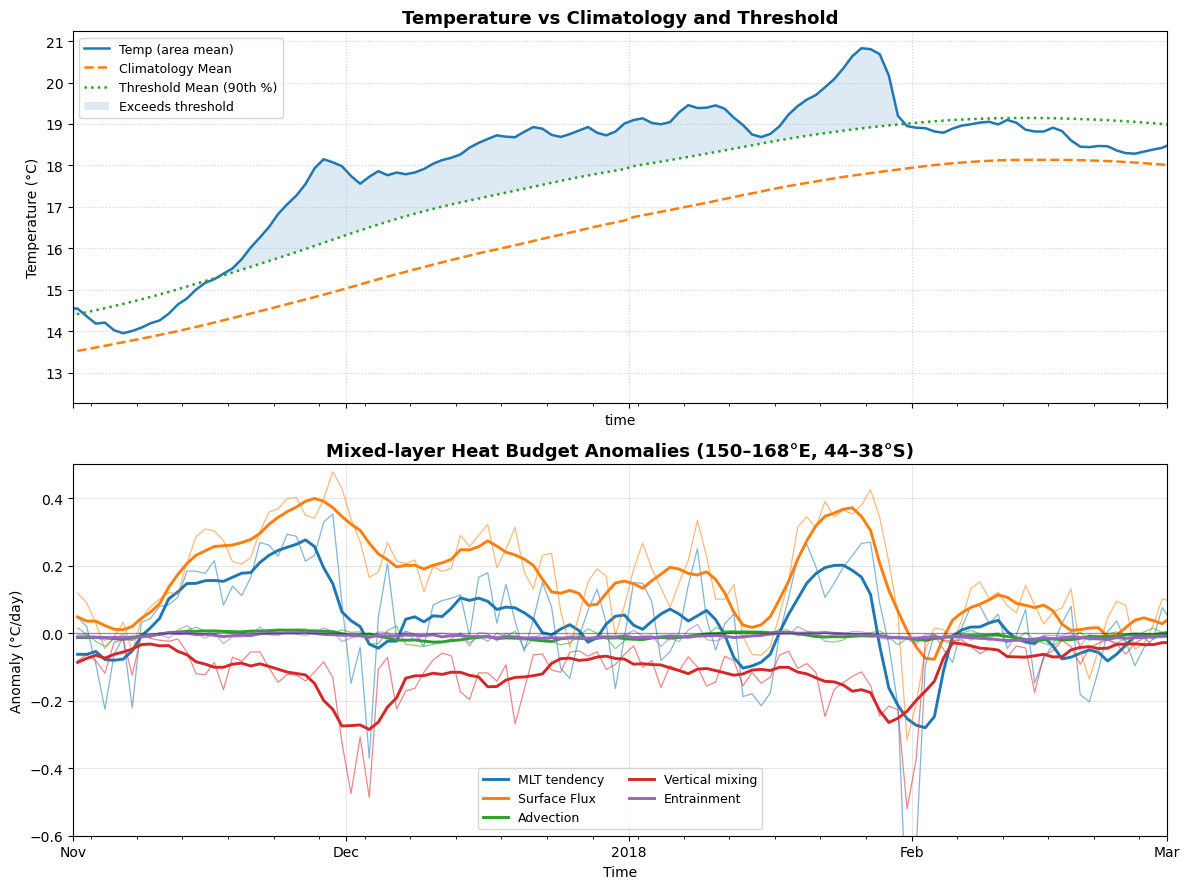

In [21]:
# ---------------- CONFIG ----------------
t0, t1 = '2017-11-01', '2018-03-01'
order  = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------------- DAILY SERIES (RAW) + 31D SMOOTH ----------------
smooth_full = box_series.rolling(time=7, center=True, min_periods=15).mean()
box_win     = box_series.sel(time=slice(t0, t1))
smooth_win  = smooth_full.sel(time=slice(t0, t1))

# Optional: sanity check that all variables exist after rename
missing = [n for n in order if n not in box_win]
if missing:
    raise KeyError(f"These variables are missing from box_win: {missing}")

# ---------------- SMOOTH ANNUAL CLIMATOLOGY (12 → daily) ----------------
# Subset monthly climatology to your box
lon_min_ds, lon_max_ds = -210, -192
lat_min,     lat_max   = -44,  -38
vars_needed = ['mlt_tendency','advection','vert_mixing','entrainment','surface_flux','sw_pen']

clim_box = budget_clim[vars_needed].sel(
    xt_ocean=slice(lon_min_ds, lon_max_ds),
    yt_ocean=slice(lat_min, lat_max)
)

# area weights and area-mean monthly values
w = np.cos(np.deg2rad(clim_box['yt_ocean']))
clim_monthly = xr.Dataset({
    'MLT tendency' : clim_box['mlt_tendency']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Surface Flux' : (clim_box['surface_flux'] + clim_box['sw_pen']).weighted(w).mean(('yt_ocean','xt_ocean')),
    'Advection'    : clim_box['advection']          .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Vertical mixing': clim_box['vert_mixing']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Entrainment'  : clim_box['entrainment']        .weighted(w).mean(('yt_ocean','xt_ocean')),
})

# collapse to 12 months, pad for periodicity, interpolate to a daily-like cycle
clim_by_month = clim_monthly.groupby('time.month').mean('time').assign_coords(month=np.arange(1, 13))
dec = clim_by_month.sel(month=12).expand_dims(month=[0])   # copy Dec at 0
jan = clim_by_month.sel(month=1 ).expand_dims(month=[13])  # copy Jan at 13
clim_padded = xr.concat([dec, clim_by_month, jan], dim='month')

days = np.linspace(1, 12, 365)                   # daily positions through the year
clim_smooth = clim_padded.interp(month=days)     # continuous annual cycle for each term

# map smooth annual cycle to the daily window using DOY (0..364)
doys = ((box_win['time'].dt.dayofyear - 1) % 365)
clim_daily = xr.Dataset({
    name: clim_smooth[name].isel(month=doys).assign_coords(time=box_win['time'])
    for name in order
})
# optional tiny cosmetic smoothing
clim_daily = clim_daily.rolling(time=31, center=True, min_periods=1).mean()

# ---------------- ANOMALIES (raw - climatology) ----------------
anom_win        = xr.Dataset({name: box_win[name]        - clim_daily[name] for name in order})
anom_smooth_win = xr.Dataset({name: anom_win[name].rolling(time=7, center=True, min_periods=3).mean()
                              for name in order})

# ---------------- PLOT: TWO STACKED AXES ----------------
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)

# ===== TOP PANEL: Temp vs Climatology & Threshold with phases =====
temp_mean.plot(ax=ax1, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax1, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax1, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
valid  = np.isfinite(y_temp) & np.isfinite(y_thr)
ax1.fill_between(t[valid], y_thr[valid], y_temp[valid],
                 where=(y_temp[valid] > y_thr[valid]), alpha=0.15, label='Exceeds threshold')

# annotate events (expects precomputed `events`)
# anom_top = (y_temp[valid] - y_thr[valid])
# anom_series = pd.Series(anom_top, index=pd.to_datetime(t[valid]))
# for k, (t_start, t_end) in enumerate(events, start=1):
#     seg = anom_series.loc[t_start:t_end]
#     if seg.empty:
#         continue
#     t_peak = seg.idxmax()
#     ax1.axvspan(t_start, t_peak, alpha=0.10, facecolor='tab:orange', label='Onset'   if k==1 else None)
#     ax1.axvspan(t_peak,  t_end,  alpha=0.10, facecolor='tab:green',  label='Decline' if k==1 else None)
#     ax1.axvline(t_peak, color='tab:red', linestyle='-', linewidth=1.2, alpha=0.8,   label='Peak'    if k==1 else None)
#     ax1.scatter([t_start, t_peak, t_end],
#                 [temp_mean.sel(time=t_start).item(),
#                  temp_mean.sel(time=t_peak).item(),
#                  temp_mean.sel(time=t_end).item()],
#                 s=25, zorder=5, color='k')

# optional vertical marker
#vdate = dt.datetime(2017, 11, 29)
#ax1.axvline(vdate, color='k', linestyle='--', linewidth=1.2, alpha=0.8)

ax1.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# ===== BOTTOM PANEL: Budget ANOMALIES (raw - clim), raw thin + 31d thick =====
for i, name in enumerate(order):
    c = colors[i % len(colors)]
    # raw anomaly (thin; no legend)
    anom_win[name].plot(ax=ax2, linewidth=0.9, alpha=0.55, color=c, label='_nolegend_')
    # smoothed anomaly (thick; legend entry)
    anom_smooth_win[name].plot(ax=ax2, linewidth=2.1, color=c, label=name)

ax2.axhline(0, lw=1, color='k', alpha=0.35)
ax2.set_title('Mixed-layer Heat Budget Anomalies (150–168°E, 44–38°S)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Anomaly (°C/day)')
ax2.set_ylim([-.6,.5])
ax2.grid(True, alpha=0.3)

# ----- shared x-axis limits + formatting -----
ax2.set_xlim(pd.Timestamp(t0), pd.Timestamp(t1))
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax2.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax2.set_xlabel('Time')

ax2.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.savefig("access-om2-sst-budget//TAS_MHW_example.png", dpi=300, bbox_inches="tight", pad_inches=0.1)

/jobfs/156022541.gadi-pbs/ipykernel_1388372/3960424624.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


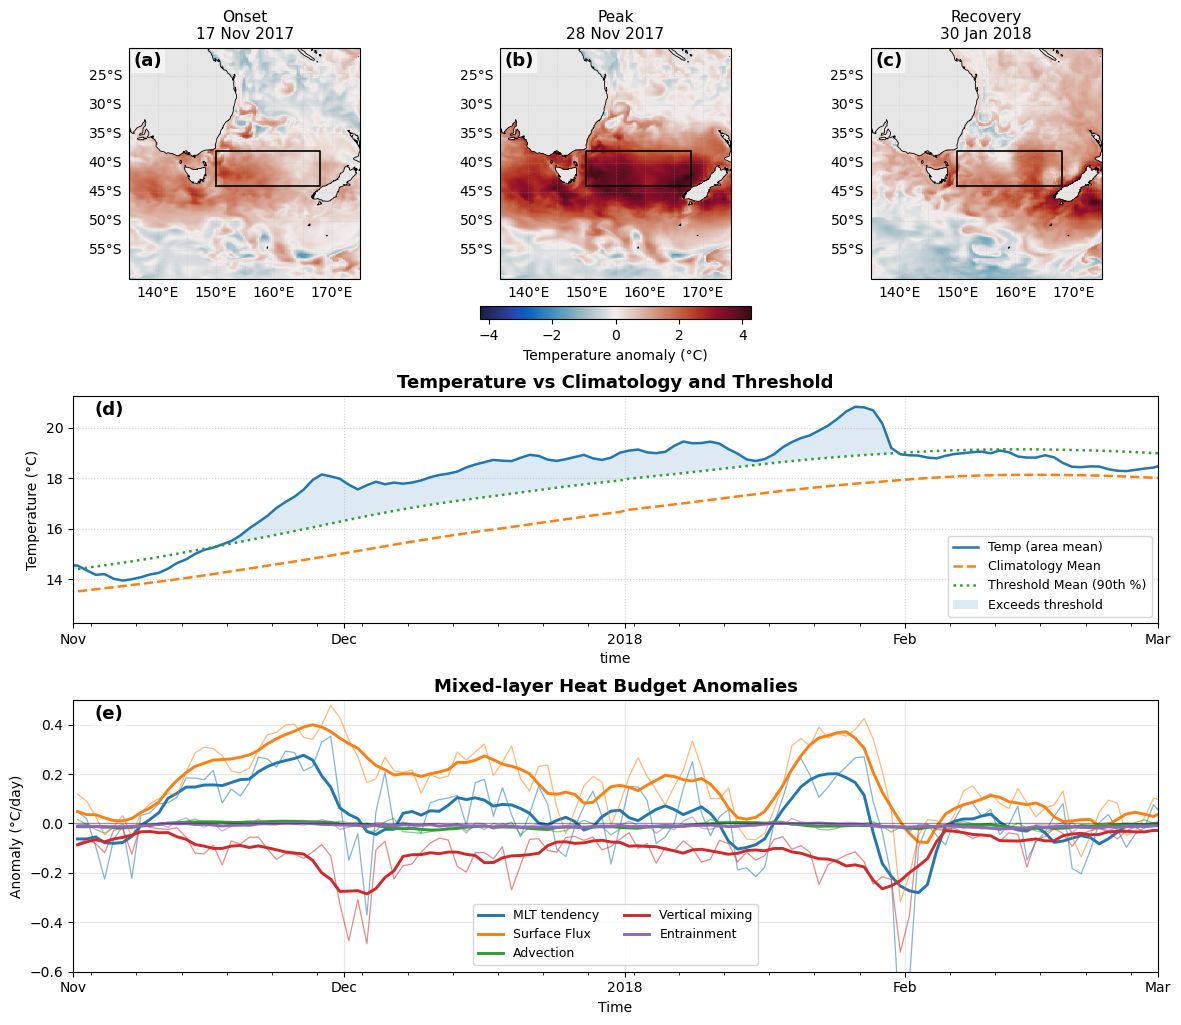

In [26]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(
    nrows=3, ncols=3,
    height_ratios=[1.2, 1.0, 1.2],  # maps, top TS, bottom TS
    hspace=0.3, wspace=0.08
)

# -------------------------------------------------------------------
# 1. Three spatial plots of temperature anomaly (onset / peak / recovery)
# -------------------------------------------------------------------

# Ensure we have the box bounds in native grid coordinates
try:
    lon_left, lon_right, lat_bot, lat_top
except NameError:
    # fall back to the same logic used earlier
    lon_min_e, lon_max_e = 150.0, 168.0
    lat_min,   lat_max   = -44.0, -38.0
    lon_left  = map_lon_to_ds(lon_min_e, clim['xt_ocean'])
    lon_right = map_lon_to_ds(lon_max_e, clim['xt_ocean'])
    lat_bot,  lat_top    = sorted([lat_min, lat_max])

ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)
ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)
ax_map3 = fig.add_subplot(gs[0, 2], projection=proj)
map_axes = [ax_map1, ax_map2, ax_map3]

# Use the main MHW phases found earlier
phase_dates  = [t_start,       t_peak,        t_end]
phase_labels = ['Onset', 'Peak', 'Recovery']

anom_fields = []
for d in phase_dates:
    # day-of-year climatology
    doy = pd.to_datetime(d).dayofyear
    clim_on_date = clim.temp.sel(dayofyear=doy)
    temp_on_date = temp.temp.sel(time=d, method='nearest')
    anom = temp_on_date - clim_on_date
    anom_fields.append(anom)

# Symmetric color range across all three anomaly fields
amax = max(float(np.nanmax(np.abs(a.values))) for a in anom_fields)
vmin_anom, vmax_anom = -amax, amax

for ax, anom, phase, d in zip(map_axes, anom_fields, phase_labels, phase_dates):
    try:
        plotmap(anom, ax=ax, lon_name='xt_ocean', lat_name='yt_ocean')
    except TypeError:
        plotmap(anom, ax=ax)

    im = anom.plot.pcolormesh(
        ax=ax, transform=proj,
        cmap=cmo.balance, vmin=vmin_anom, vmax=vmax_anom,
        add_colorbar=False
    )

    # Draw the TAS box
    box_lons = [lon_left, lon_right, lon_right, lon_left, lon_left]
    box_lats = [lat_bot,  lat_bot,   lat_top,   lat_top,  lat_bot]
    ax.plot(box_lons, box_lats, color='black', linewidth=1.2, transform=proj)

    # Title with phase + date
    date_str = pd.to_datetime(d).strftime('%-d %b %Y')
    ax.set_title(f'{phase}\n{date_str}', fontsize=11)

# Shared colourbar for anomaly maps
cbar = fig.colorbar(
    im, ax=map_axes, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.set_label('Temperature anomaly (°C)')

# -------------------------------------------------------------------
# 2. Two-panel time-series: same as cell 22, but slotted under the maps
# -------------------------------------------------------------------

ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[2, :], sharex=ax1)

# ===== TOP PANEL: Temp vs Climatology & Threshold with exceedance =====
temp_mean.plot(ax=ax1, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax1, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax1, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
valid  = np.isfinite(y_temp) & np.isfinite(y_thr)

ax1.fill_between(
    t[valid], y_thr[valid], y_temp[valid],
    where=(y_temp[valid] > y_thr[valid]),
    alpha=0.15, label='Exceeds threshold'
)

ax1.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# ===== BOTTOM PANEL: Budget anomalies (same as in cell 22) =====
for i, name in enumerate(order):
    c = colors[i % len(colors)]
    # raw anomaly (thin; no legend)
    anom_win[name].plot(ax=ax2, linewidth=0.9, alpha=0.55, color=c, label='_nolegend_')
    # smoothed anomaly (thick; legend entry)
    anom_smooth_win[name].plot(ax=ax2, linewidth=2.1, color=c, label=name)

ax2.axhline(0, lw=1, color='k', alpha=0.35)
ax2.set_title('Mixed-layer Heat Budget Anomalies', fontsize=13, fontweight='bold')
ax2.set_ylabel('Anomaly (°C/day)')
ax2.set_ylim([-.6, .5])
ax2.grid(True, alpha=0.3)

# Shared x-axis formatting for both TS panels
ax2.set_xlim(pd.Timestamp(t0), pd.Timestamp(t1))
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax2.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax2.set_xlabel('Time')

ax2.legend(ncol=2, fontsize=9)
# -------------------------------------------------------------------
# Add panel labels: (a), (b), (c), ...
# -------------------------------------------------------------------

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']
axes_to_label = [ax_map1, ax_map2, ax_map3, ax1, ax2]

for ax, label in zip(axes_to_label, panel_labels):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=13, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
    )
#fig.suptitle('TAS MHW: Anomaly Maps and Mixed-layer Heat Budget', y=0.995, fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])

# Optional: save to file
plt.savefig("/home/561/nm5072/access-om2-sst-budget/TAS_MHW_combined_figure.png", dpi=300, bbox_inches="tight", pad_inches=0.1)

In [23]:
pwd

'/home/561/nm5072'